In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.feature_selection import SelectKBest, f_classif

try:
    from imblearn.over_sampling import SMOTE
    smote_available = True
except:
    smote_available = False
    print("Note: imbalanced-learn not installed. SMOTE will be skipped.")

import warnings
warnings.filterwarnings('ignore')

In [7]:
#UPLOAD AND LOAD YOUR DATASET

from google.colab import files
import io

print("="*50)
print("UPLOAD YOUR DATASET")
print("="*50)

# Option 1: Upload from your computer
print("\n📂 Please upload your dataset file (CSV format):")
uploaded = files.upload()

# Get the filename
file_name = list(uploaded.keys())[0]
print(f"\n✅ File uploaded: {file_name}")

# Load the dataset
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# OR Option 2: If you have a file path in Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# file_path = '/content/drive/MyDrive/your_dataset.csv'  # CHANGE THIS PATH
# df = pd.read_csv(file_path)

print("\n" + "="*50)
print("DATASET LOADED SUCCESSFULLY!")
print("="*50)
print(f"📊 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n📋 Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

UPLOAD YOUR DATASET

📂 Please upload your dataset file (CSV format):


Saving smalldata.csv to smalldata.csv

✅ File uploaded: smalldata.csv

DATASET LOADED SUCCESSFULLY!
📊 Dataset Shape: 174 rows × 25 columns

📋 Column Names:
   1. student_id
   2. username
   3. course_id
   4. quiz_id
   5. unknown
   6. attempt_no
   7. status
   8. result
   9. score_obtained
   10. total_score
   11. correct_answers
   12. wrong_answers
   13. partial_marks
   14. max_marks
   15. level
   16. badge
   17. rank
   18. unknown.1
   19. unknown.2
   20. skipped
   21. time_taken
   22. total_time
   23. Unnamed: 22
   24. question_set_id
   25. type


In [8]:
#CONFIGURE TARGET AND FEATURES


print("="*50)
print("DATASET CONFIGURATION")
print("="*50)

# Display first few rows
print("\n🔍 First 5 rows of your dataset:")
print(df.head())

# Ask user to specify target column
print("\n" + "="*50)
print("⚠️  IMPORTANT: Please specify your target column")
print("="*50)
print("\nThe target column is what you want to predict.")
print("Available columns:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

# Get target column name from user
target_col = input("\n👉 Enter the EXACT column name for target variable: ").strip()

# Verify if column exists
if target_col not in df.columns:
    print(f"\n❌ Error: '{target_col}' not found in columns!")
    print("Please run this cell again with correct column name.")
else:
    print(f"\n✅ Target column set to: {target_col}")

# Check if target is categorical or numerical
print(f"\n📊 Target column data type: {df[target_col].dtype}")
print(f"📊 Target column unique values: {df[target_col].nunique()}")
print(f"📊 Target column sample values: {df[target_col].unique()[:10]}")

# Determine problem type
if df[target_col].dtype == 'object' or df[target_col].nunique() < 20:
    problem_type = "classification"
    print(f"\n🎯 Problem Type: CLASSIFICATION (predicting categories)")
else:
    problem_type = "regression"
    print(f"\n🎯 Problem Type: REGRESSION (predicting numerical values)")

# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

print(f"\n✅ Features (X): {X.shape[1]} columns")
print(f"✅ Target (y): {y.shape[0]} samples")

# Ask if user wants to specify feature columns (optional)
use_all_features = input("\n👉 Use all columns as features? (yes/no): ").strip().lower()

if use_all_features == 'no':
    print("\n📋 Available features:")
    for i, col in enumerate(X.columns, 1):
        print(f"   {i}. {col}")

    exclude_cols = input("\n👉 Enter columns to EXCLUDE (comma-separated, or press Enter for none): ").strip()
    if exclude_cols:
        exclude_list = [col.strip() for col in exclude_cols.split(',')]
        X = X.drop(columns=exclude_list)
        print(f"✅ Features after exclusion: {X.shape[1]} columns")

DATASET CONFIGURATION

🔍 First 5 rows of your dataset:
                             student_id      username  \
0                                   NaN           NaN   
1  71e84380-eb93-4eb8-8e99-8371f21c685c    iqra-c78tx   
2  71e84380-eb93-4eb8-8e99-8371f21c685c    iqra-c78tx   
3              65026fa40be88c76ad34475f  iqzone-pu46b   
4              64fbde0691abce28fb5db062  iqzone-pu46b   

                  course_id                   quiz_id  unknown  attempt_no  \
0                       NaN                       NaN      NaN         NaN   
1  6515b62a135366b610433a59  6515b62b135366b610433c55      NaN         1.0   
2  64fb18cb45c426647568c5e8  64fb20e045c42664756a9509      NaN         1.0   
3  64aeafe44a72a018104b59ff  64e0c5e00e7e50a5300183e0      NaN         1.0   
4  640ee791ca737b9f099087c3  640f03ee102b84e324929a13      NaN         1.0   

        status  result  score_obtained  total_score  ...   badge  rank  \
0          NaN     NaN             NaN          NaN  ...   

EXPLORATORY DATA ANALYSIS

📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   student_id       165 non-null    object 
 1   username         165 non-null    object 
 2   course_id        165 non-null    object 
 3   quiz_id          165 non-null    object 
 4   unknown          0 non-null      float64
 5   attempt_no       165 non-null    float64
 6   status           165 non-null    object 
 7   result           165 non-null    object 
 8   score_obtained   165 non-null    float64
 9   total_score      165 non-null    float64
 10  correct_answers  165 non-null    float64
 11  wrong_answers    165 non-null    float64
 12  partial_marks    165 non-null    float64
 13  max_marks        165 non-null    float64
 14  level            165 non-null    object 
 15  badge            165 non-null    object 
 16  rank        

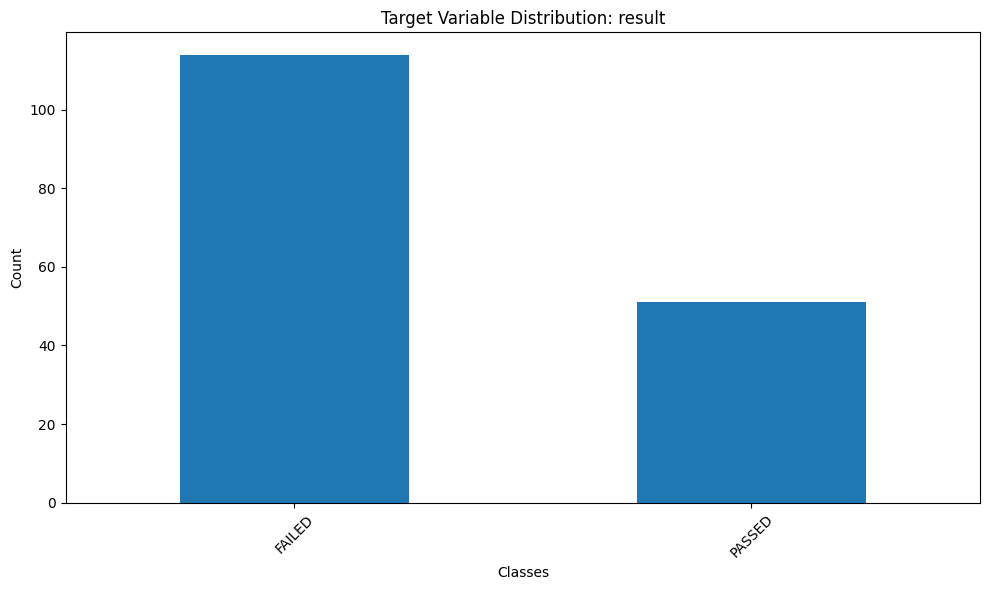


📊 Feature Types:
   Numerical features: 13
   Categorical features: 11


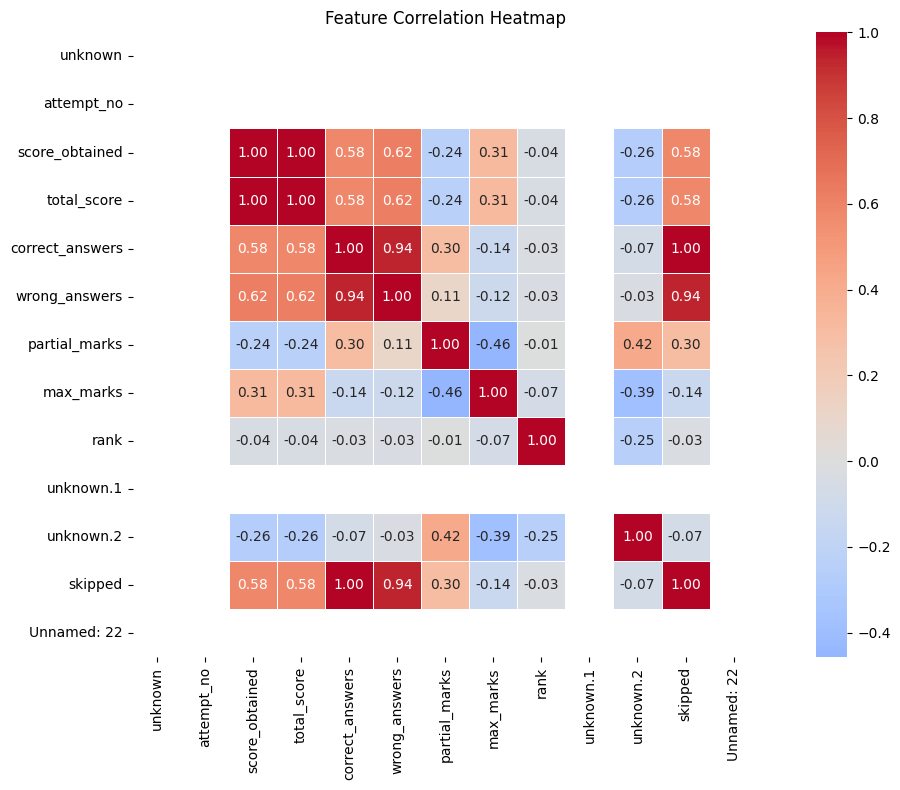

In [9]:
#EXPLORATORY DATA ANALYSIS


print("="*50)
print("EXPLORATORY DATA ANALYSIS")
print("="*50)

# 1. Basic information
print("\n📋 Dataset Information:")
print(df.info())

# 2. Check for missing values
print("\n❓ Missing Values:")
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percent
})
print(missing_df[missing_df['Missing Values'] > 0])

# 3. Statistical summary
print("\n📈 Statistical Summary (Numerical Features):")
print(df.describe())

# 4. Check class distribution (for classification)
if problem_type == "classification":
    print("\n🎯 Target Variable Distribution:")
    target_dist = df[target_col].value_counts()
    print(target_dist)

    # Plot class distribution
    plt.figure(figsize=(10, 6))
    target_dist.plot(kind='bar')
    plt.title(f'Target Variable Distribution: {target_col}')
    plt.xlabel('Classes')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 5. Numerical features analysis
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"\n📊 Feature Types:")
print(f"   Numerical features: {len(numerical_cols)}")
print(f"   Categorical features: {len(categorical_cols)}")

# 6. Correlation heatmap (if numerical features exist)
if len(numerical_cols) > 1:
    plt.figure(figsize=(12, 8))
    correlation_matrix = X[numerical_cols].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                fmt='.2f', square=True, linewidths=0.5)
    plt.title('Feature Correlation Heatmap')
    plt.tight_layout()
    plt.show()

In [10]:
#DATA PREPROCESSING


print("="*50)
print("DATA PREPROCESSING")
print("="*50)

# Check if df is defined, if not, inform the user to run previous cells
if 'df' not in globals():
    raise NameError("Variable 'df' is not defined. Please ensure 'STEP 2: UPLOAD AND LOAD YOUR DATASET' (cell WyJuYZ1y1o-5) has been executed successfully.")

# Re-initialize X and y from the original df to ensure consistency and correct types
# This is crucial for idempotency if the cell is run multiple times.
_X = df.drop(columns=[target_col])
_y = df[target_col]

# Convert potential string representations of NaN to np.nan
if _y.dtype == 'object':
    _y = _y.replace(['nan', 'NaN', 'None', ''], np.nan)

# Handle missing values in target variable first
print("\n✅ Step 0: Handling Missing Values in Target Variable")
initial_rows = df.shape[0]
if _y.isnull().any():
    nan_target_indices = _y[_y.isnull()].index
    _X = _X.drop(nan_target_indices)
    _y = _y.drop(nan_target_indices)
    print(f"   • Dropped {len(nan_target_indices)} rows where target variable '{target_col}' was missing.")
    print(f"   • Remaining samples: {_y.shape[0]}")
else:
    print("   • No missing values found in target variable.")

X = _X # Update the global X
y = _y # Update the global y

# Handle missing values in features
print("\n✅ Step 1: Handling Missing Values in Features")
if X.isnull().sum().sum() > 0:
    # Identify and drop columns with 100% missing values first
    all_nan_cols = X.columns[X.isnull().all()].tolist()
    if all_nan_cols:
        print(f"   • Dropping columns with 100% missing values: {', '.join(all_nan_cols)}")
        X = X.drop(columns=all_nan_cols)
        # Re-evaluate numerical and categorical columns after dropping
        numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
        categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

    # For numerical columns
    if numerical_cols:
        num_imputer = SimpleImputer(strategy='median')
        # Fix: Convert the NumPy array output of fit_transform back to DataFrame
        X[numerical_cols] = pd.DataFrame(num_imputer.fit_transform(X[numerical_cols]),
                                         columns=numerical_cols, index=X.index)
        print(f"   • Handled missing values in {len(numerical_cols)} numerical columns")

    # For categorical columns
    if categorical_cols:
        cat_imputer = SimpleImputer(strategy='most_frequent')
        X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])
        print(f"   • Handled missing values in {len(categorical_cols)} categorical columns")
else:
    print("   • No missing values found in features.")

# Encode categorical features
print("\n✅ Step 2: Encoding Categorical Variables")
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"   • Encoded: {col}")

# Encode target variable if it's categorical
if problem_type == "classification" and y.dtype == 'object':
    target_encoder = LabelEncoder()
    y = target_encoder.fit_transform(y)
    print(f"\n   • Target variable encoded: {target_col}")
    print(f"   • Classes: {dict(enumerate(target_encoder.classes_))}")

# Split the data
print("\n✅ Step 3: Train-Test Split")
test_size = float(input("\n👉 Enter test set size (e.g., 0.2 for 20%, default 0.2): ") or "0.2")
random_state = int(input("👉 Enter random seed (e.g., 42, default 42): ") or "42")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state,
    stratify=y if problem_type == "classification" else None
)

print(f"   • Training set: {X_train.shape[0]} samples")
print(f"   • Testing set: {X_test.shape[0]} samples")

# Feature scaling
print("\n✅ Step 4: Feature Scaling")
synced_numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[synced_numerical_cols])
X_test_scaled = scaler.transform(X_test[synced_numerical_cols])
# Re-assign scaled numerical columns back to DataFrames
X_train[synced_numerical_cols] = X_train_scaled
X_test[synced_numerical_cols] = X_test_scaled
print("   • Features standardized (mean=0, std=1)")

# Handle imbalanced data (for classification)
if problem_type == "classification" and smote_available:
    class_counts = pd.Series(y_train).value_counts()
    imbalance_ratio = max(class_counts) / min(class_counts)

    if imbalance_ratio > 1.5:
        print("\n✅ Step 5: Handling Imbalanced Data")
        print(f"   • Imbalance ratio: {imbalance_ratio:.2f}")
        apply_smote = input("   👉 Apply SMOTE to balance classes? (yes/no): ").strip().lower()

        if apply_smote == 'yes':
            smote = SMOTE(random_state=random_state)
            X_train_scaled, y_train = smote.fit_resample(X_train, y_train) # Use X_train, not X_train_scaled here after scaling
            print(f"   • After SMOTE: {X_train_scaled.shape[0]} samples")
            print(f"   • New class distribution: {pd.Series(y_train).value_counts().tolist()}")
    else:
        print("\n✅ Step 5: Dataset is balanced")
        print(f"   • Class distribution ratio: {imbalance_ratio:.2f}")

DATA PREPROCESSING

✅ Step 0: Handling Missing Values in Target Variable
   • Dropped 9 rows where target variable 'result' was missing.
   • Remaining samples: 165

✅ Step 1: Handling Missing Values in Features
   • Dropping columns with 100% missing values: unknown, unknown.1, Unnamed: 22
   • Handled missing values in 10 numerical columns
   • Handled missing values in 11 categorical columns

✅ Step 2: Encoding Categorical Variables
   • Encoded: student_id
   • Encoded: username
   • Encoded: course_id
   • Encoded: quiz_id
   • Encoded: status
   • Encoded: level
   • Encoded: badge
   • Encoded: time_taken
   • Encoded: total_time
   • Encoded: question_set_id
   • Encoded: type

   • Target variable encoded: result
   • Classes: {0: 'FAILED', 1: 'PASSED'}

✅ Step 3: Train-Test Split

👉 Enter test set size (e.g., 0.2 for 20%, default 0.2): 0.4
👉 Enter random seed (e.g., 42, default 42): 22
   • Training set: 99 samples
   • Testing set: 66 samples

✅ Step 4: Feature Scaling
   • 

MODEL TRAINING

🔧 Training: Logistic Regression
   ✅ Training Score: 0.9798
   ✅ Testing Score: 0.9697
   ✅ 5-Fold CV Score: 0.9500

🔧 Training: Decision Tree
   ✅ Training Score: 1.0000
   ✅ Testing Score: 0.9697
   ✅ 5-Fold CV Score: 0.9800

🔧 Training: Random Forest
   ✅ Training Score: 1.0000
   ✅ Testing Score: 1.0000
   ✅ 5-Fold CV Score: 0.9600

🔧 Training: SVM
   ✅ Training Score: 0.9697
   ✅ Testing Score: 0.9545
   ✅ 5-Fold CV Score: 0.9295

🔧 Training: KNN
   ✅ Training Score: 0.9394
   ✅ Testing Score: 0.9697
   ✅ 5-Fold CV Score: 0.9400

🔧 Training: Gradient Boosting
   ✅ Training Score: 1.0000
   ✅ Testing Score: 0.9697
   ✅ 5-Fold CV Score: 0.9800

🔧 Training: AdaBoost
   ✅ Training Score: 1.0000
   ✅ Testing Score: 0.9848
   ✅ 5-Fold CV Score: 0.9800

🔧 Training: XGBoost
   ✅ Training Score: 1.0000
   ✅ Testing Score: 0.9697
   ✅ 5-Fold CV Score: 0.9900

MODEL COMPARISON SUMMARY
              Model  Train Score  Test Score  CV Score
      Random Forest     1.000000    1

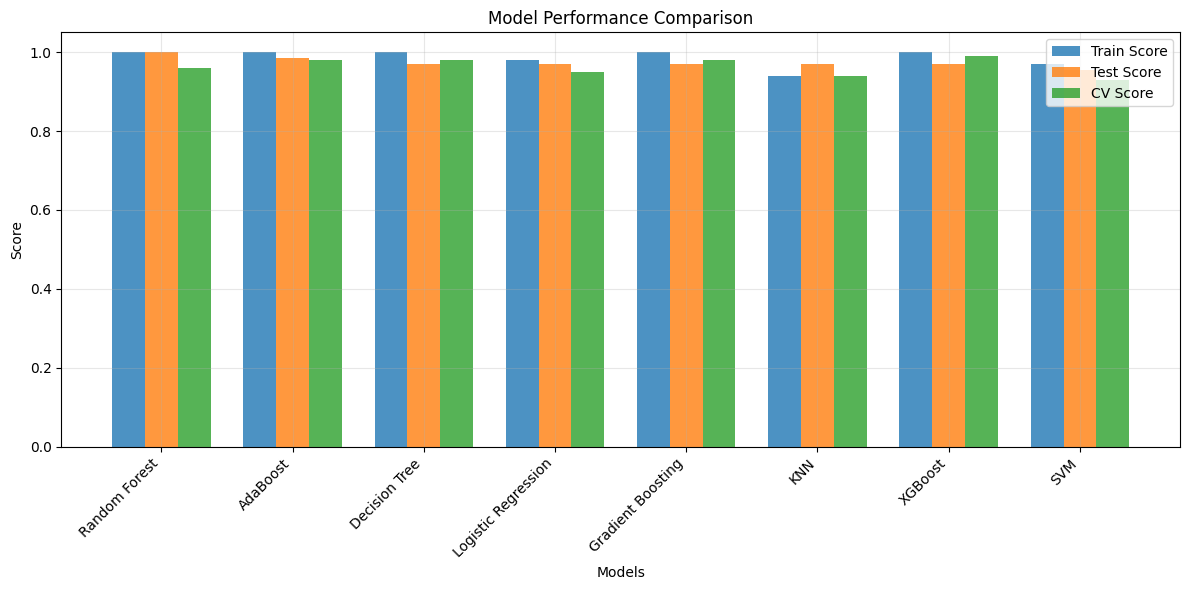


🏆 Best Model: Random Forest
   Test Score: 1.0000


In [11]:
#TRAIN AND COMPARE MODELS


print("="*50)
print("MODEL TRAINING")
print("="*50)

# Select models based on problem type
if problem_type == "classification":
    models = {
        'Logistic Regression': LogisticRegression(random_state=random_state, max_iter=1000),
        'Decision Tree': DecisionTreeClassifier(random_state=random_state),
        'Random Forest': RandomForestClassifier(random_state=random_state, n_estimators=100),
        'SVM': SVC(random_state=random_state, probability=True),
        'KNN': KNeighborsClassifier(),
        'Gradient Boosting': GradientBoostingClassifier(random_state=random_state),
        'AdaBoost': AdaBoostClassifier(random_state=random_state),
        'XGBoost': XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric='logloss')
    }
else:  # regression
    from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
    from sklearn.linear_model import LinearRegression, Ridge, Lasso
    from sklearn.svm import SVR
    from sklearn.metrics import mean_squared_error, r2_score

    models = {
        'Linear Regression': LinearRegression(),
        'Ridge Regression': Ridge(),
        'Lasso Regression': Lasso(),
        'Random Forest': RandomForestRegressor(random_state=random_state),
        'Gradient Boosting': GradientBoostingRegressor(random_state=random_state),
        'SVR': SVR()
    }

results = {}
train_scores = {}
test_scores = {}
cv_scores = {}

for name, model in models.items():
    print(f"\n🔧 Training: {name}")

    try:
        # Train the model
        model.fit(X_train_scaled, y_train)

        # Predict
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)

        # Evaluate
        if problem_type == "classification":
            train_score = accuracy_score(y_train, y_train_pred)
            test_score = accuracy_score(y_test, y_test_pred)
            cv_score = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
        else:  # regression
            train_score = r2_score(y_train, y_train_pred)
            test_score = r2_score(y_test, y_test_pred)
            cv_score = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2').mean()

        train_scores[name] = train_score
        test_scores[name] = test_score
        cv_scores[name] = cv_score

        results[name] = {
            'model': model,
            'train_score': train_score,
            'test_score': test_score,
            'cv_score': cv_score
        }

        print(f"   ✅ Training Score: {train_score:.4f}")
        print(f"   ✅ Testing Score: {test_score:.4f}")
        print(f"   ✅ 5-Fold CV Score: {cv_score:.4f}")

    except Exception as e:
        print(f"   ❌ Error: {str(e)[:100]}")

# Compare results
comparison_df = pd.DataFrame({
    'Model': list(train_scores.keys()),
    'Train Score': list(train_scores.values()),
    'Test Score': list(test_scores.values()),
    'CV Score': list(cv_scores.values())
})
comparison_df = comparison_df.sort_values('Test Score', ascending=False)

print("\n" + "="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)
print(comparison_df.to_string(index=False))

# Plot comparison
plt.figure(figsize=(12, 6))
x = range(len(comparison_df))
width = 0.25

plt.bar([i - width for i in x], comparison_df['Train Score'],
        width, label='Train Score', alpha=0.8)
plt.bar(x, comparison_df['Test Score'],
        width, label='Test Score', alpha=0.8)
plt.bar([i + width for i in x], comparison_df['CV Score'],
        width, label='CV Score', alpha=0.8)

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, comparison_df['Model'], rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Best model
best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Test Score: {comparison_df.iloc[0]['Test Score']:.4f}")

In [12]:
#HYPERPARAMETER TUNING

print("="*50)
print("HYPERPARAMETER TUNING")
print("="*50)

tune_model = input(f"\n👉 Tune {best_model_name} for better performance? (yes/no): ").strip().lower()

if tune_model == 'yes':
    print(f"\n🔍 Tuning: {best_model_name}")

    # Define parameter grids based on model type
    if best_model_name == 'Random Forest':
        param_grid = {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5, 10]
        }
    elif best_model_name == 'SVM':
        param_grid = {
            'C': [0.1, 1, 10],
            'gamma': ['scale', 'auto'],
            'kernel': ['rbf', 'linear']
        }
    elif best_model_name == 'XGBoost':
        param_grid = {
            'n_estimators': [50, 100],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1]
        }
    elif best_model_name == 'Gradient Boosting':
        param_grid = {
            'n_estimators': [50, 100],
            'max_depth': [3, 5],
            'learning_rate': [0.01, 0.1]
        }
    elif best_model_name == 'Logistic Regression':
        param_grid = {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l2']
        }
    else:
        param_grid = {}

    if param_grid:
        print("\n   Parameter grid:")
        for key, values in param_grid.items():
            print(f"   • {key}: {values}")

        grid_search = GridSearchCV(
            best_model, param_grid, cv=5,
            scoring='accuracy' if problem_type == "classification" else 'r2',
            n_jobs=-1, verbose=1
        )

        grid_search.fit(X_train_scaled, y_train)

        print(f"\n✨ Best Parameters: {grid_search.best_params_}")
        print(f"✨ Best CV Score: {grid_search.best_score_:.4f}")

        tuned_model = grid_search.best_estimator_

        # Evaluate tuned model
        y_pred_tuned = tuned_model.predict(X_test_scaled)
        if problem_type == "classification":
            tuned_score = accuracy_score(y_test, y_pred_tuned)
        else:
            tuned_score = r2_score(y_test, y_pred_tuned)

        print(f"\n📊 Tuned Model Test Score: {tuned_score:.4f}")
        print(f"📊 Original Model Test Score: {comparison_df.iloc[0]['Test Score']:.4f}")
        print(f"📊 Improvement: {tuned_score - comparison_df.iloc[0]['Test Score']:.4f}")

        best_model = tuned_model
        best_model_name = f"{best_model_name} (Tuned)"
    else:
        print("   ⚠️ No hyperparameter grid defined for this model")

HYPERPARAMETER TUNING

👉 Tune Random Forest for better performance? (yes/no): no


FINAL EVALUATION

📋 Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

      FAILED       1.00      1.00      1.00        46
      PASSED       1.00      1.00      1.00        20

    accuracy                           1.00        66
   macro avg       1.00      1.00      1.00        66
weighted avg       1.00      1.00      1.00        66



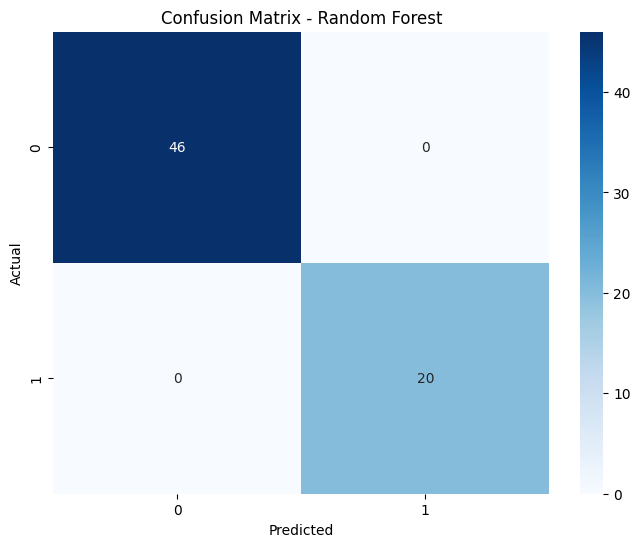

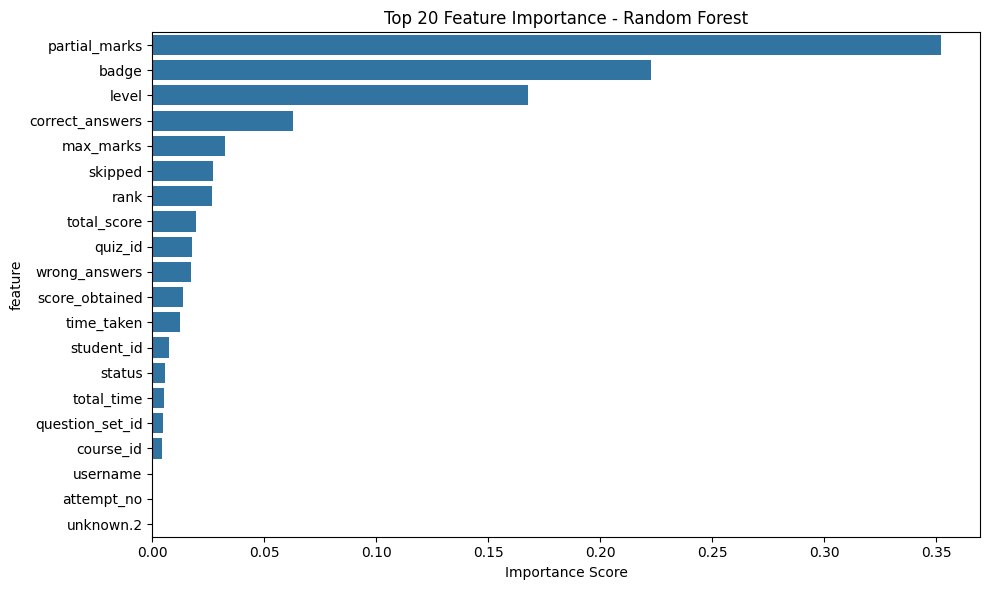


PROJECT COMPLETED SUCCESSFULLY!

📌 FINAL SUMMARY:
   • Dataset: smalldata.csv
   • Problem Type: CLASSIFICATION
   • Total Samples: 174
   • Features Used: 21
   • Best Model: Random Forest
   • Final Score: 1.0000


In [13]:
#FINAL EVALUATION

print("="*50)
print("FINAL EVALUATION")
print("="*50)

# Make final predictions
y_final_pred = best_model.predict(X_test_scaled)

if problem_type == "classification":
    # Classification metrics
    print("\n📋 Classification Report:")
    print("-"*50)
    if hasattr(target_encoder, 'classes_'):
        # Filter out NaN values from target_names
        target_names = [cls for cls in target_encoder.classes_ if pd.notna(cls)]
    else:
        target_names = None

    print(classification_report(y_test, y_final_pred, target_names=target_names))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_final_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {best_model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

else:
    # Regression metrics
    from sklearn.metrics import mean_absolute_error, mean_squared_error

    mae = mean_absolute_error(y_test, y_final_pred)
    mse = mean_squared_error(y_test, y_final_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_final_pred)

    print("\n📊 Regression Metrics:")
    print("-"*50)
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

    # Plot predictions vs actual
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_final_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'Actual vs Predicted - {best_model_name}')
    plt.tight_layout()
    plt.show()

# Feature Importance (if available)
if hasattr(best_model, 'feature_importances_'):
    plt.figure(figsize=(10, 6))
    importances = best_model.feature_importances_
    feature_names = X.columns

    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).head(20)

    sns.barplot(x='importance', y='feature', data=feature_importance_df)
    plt.title(f'Top 20 Feature Importance - {best_model_name}')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

print("\n" + "="*50)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("="*50)
print(f"\n📌 FINAL SUMMARY:")
print(f"   • Dataset: {file_name}")
print(f"   • Problem Type: {problem_type.upper()}")
print(f"   • Total Samples: {len(df)}")
print(f"   • Features Used: {X.shape[1]}")
print(f"   • Best Model: {best_model_name}")
print(f"   • Final Score: {comparison_df.iloc[0]['Test Score'] if 'tuned' not in best_model_name else tuned_score:.4f}")